In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

take thís path : /kaggle/input/luna16-full-dataset-until-23-feb-2026/subset9/subset9

load and plot

Z, Y, X Ordering: Medical scans are 3-Dimensional. When extracted to a numpy array, the shape corresponds to (Number of Slices, Height, Width). 

extracts a 2D slice from the middle of the stack [middle_slice_idx, :, :] and plots it using standard matplotlib.

In [3]:
#!pip install SimpleITK

# 2. Import required libraries
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# 3. Define the path to one of the subsets (Adjust the path based on the exact Kaggle dataset name)
# In Kaggle, datasets are usually mounted under /kaggle/input/
# Replace 'luna16' with the exact name of the dataset directory if different.
dataset_path = '/kaggle/input/luna16-full-dataset-until-23-feb-2026/subset9/subset9' 

# Find all .mhd files in the subset
mhd_files = glob.glob(os.path.join(dataset_path, '*.mhd'))


Loading scan: /kaggle/input/luna16-full-dataset-until-23-feb-2026/subset9/subset9/1.3.6.1.4.1.14519.5.2.1.6279.6001.712472578497712558367294720243.mhd
Scan shape (Z, Y, X): (158, 512, 512)


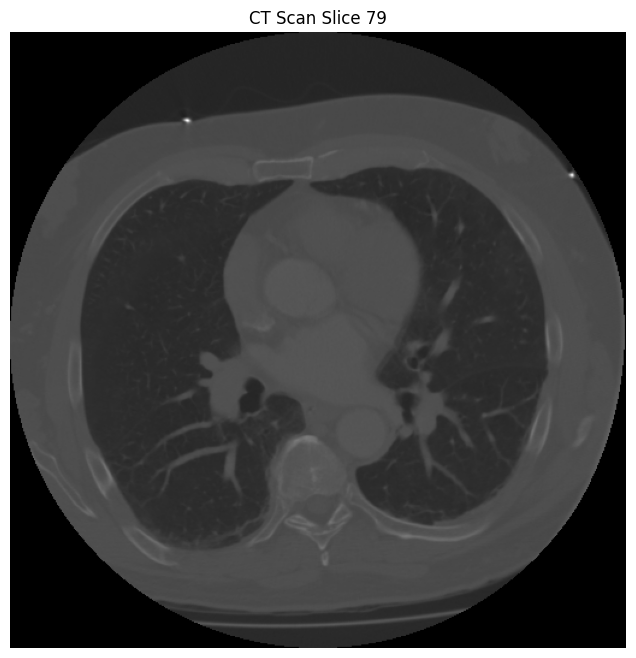

In [5]:

if not mhd_files:
    print("No .mhd files found. Please check your dataset path.")
else:
    target_scan_path = mhd_files[0]
    print(f"Loading scan: {target_scan_path}")

    itk_image = sitk.ReadImage(target_scan_path)
    image_array = sitk.GetArrayFromImage(itk_image)

    print(f"Scan shape (Z, Y, X): {image_array.shape}")

    middle_slice_idx = image_array.shape[0] // 2

    plt.figure(figsize=(8, 8))
    plt.imshow(image_array[middle_slice_idx], cmap='gray')
    plt.title(f"CT Scan Slice {middle_slice_idx}")
    plt.axis('off')
    plt.show()



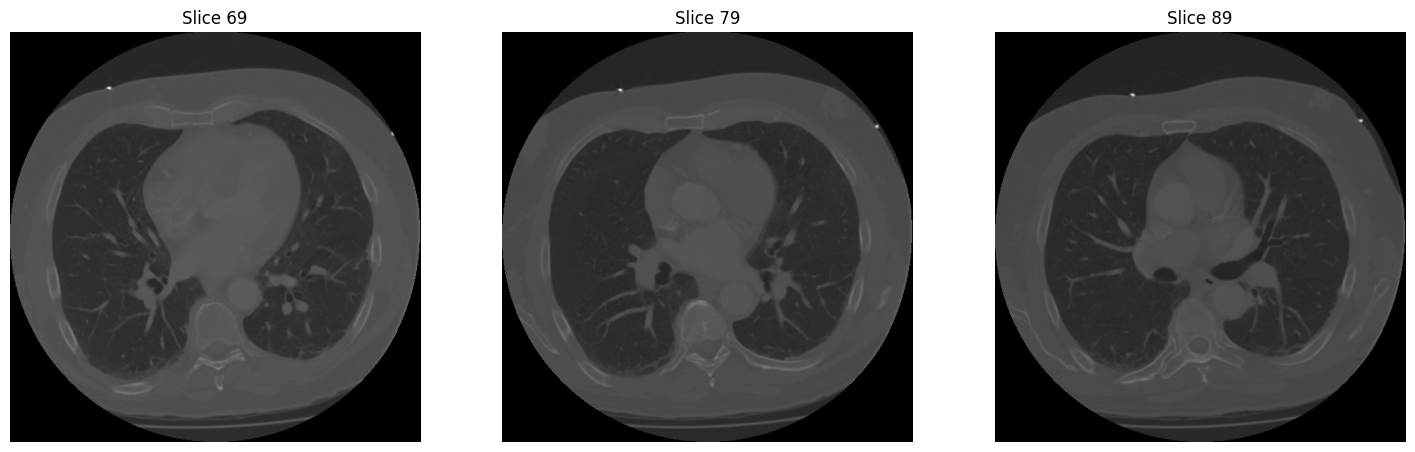

In [6]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, offset in enumerate([-10, 0, 10]):
        slice_idx = middle_slice_idx + offset
        axes[i].imshow(image_array[slice_idx], cmap='gray')
        axes[i].set_title(f"Slice {slice_idx}")
        axes[i].axis('off')
    plt.show()